AirFly Insights – Milestone 3
Route, Cancellation & Seasonal Analysis.

In [1]:
#AirFly Insights – Milestone 3
#Route, Cancellation & Seasonal Analysis.

#Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For Maps
import plotly.express as px

sns.set_style("whitegrid")

In [3]:
#Load Dataset

df = pd.read_csv('data/Flight_Dataset.csv')
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [5]:
#Ensure Required Columns Exist

# Create YEAR, MONTH if missing
if 'FL_DATE' in df.columns:
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')
    df['YEAR'] = df['FL_DATE'].dt.year
    df['MONTH'] = df['FL_DATE'].dt.month
    df['MONTH_NAME'] = df['FL_DATE'].dt.month_name()

In [7]:
#Filter Active Flights

active = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)]

In [9]:
print(active.columns)


Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'YEAR', 'MONTH', 'MONTH_NAME'],
      dtype='str')


In [11]:
active['ROUTE'] = active['ORIGIN'] + " → " + active['DEST']

In [13]:
active['ROUTE'] = active['ORIGIN'].astype(str) + " → " + active['DEST'].astype(str)

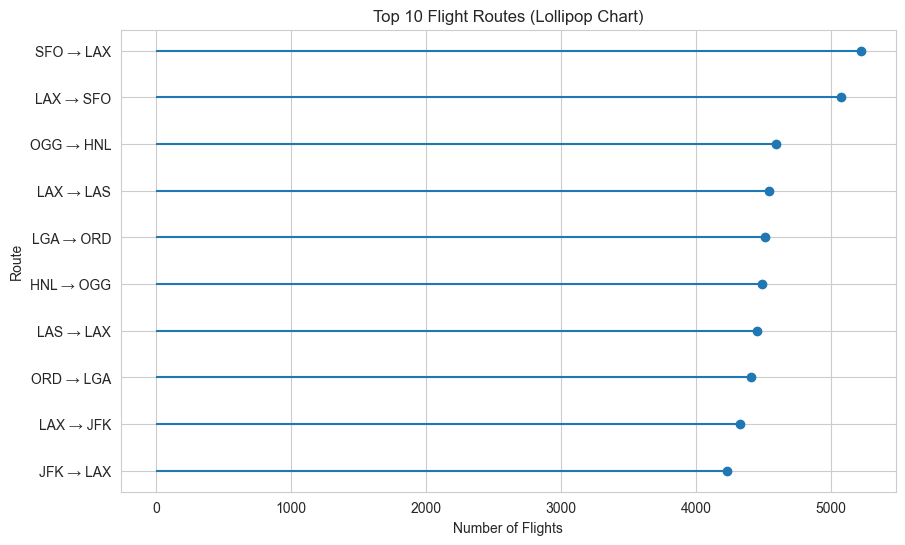

In [15]:
top_routes = active['ROUTE'].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6))
plt.hlines(y=top_routes.index, xmin=0, xmax=top_routes.values)
plt.plot(top_routes.values, top_routes.index, "o")

plt.title("Top 10 Flight Routes (Lollipop Chart)")
plt.xlabel("Number of Flights")
plt.ylabel("Route")
plt.show()

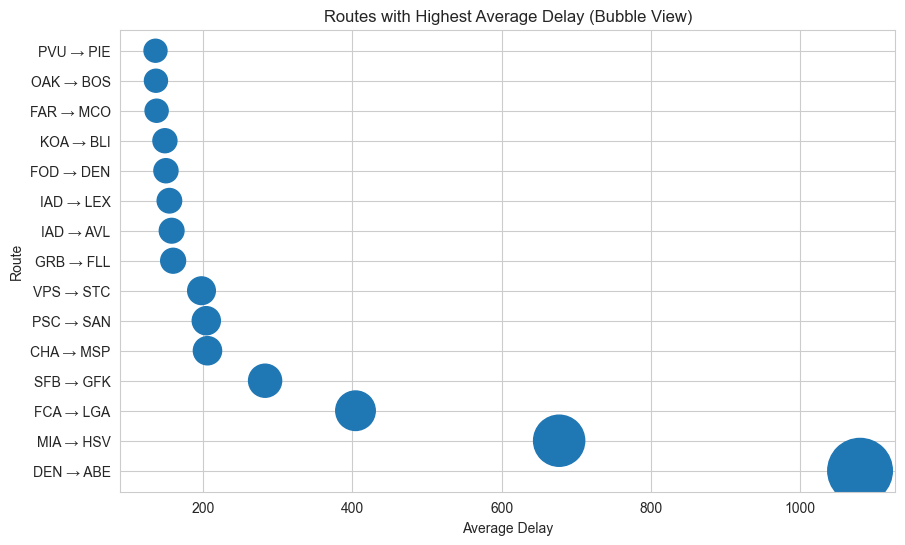

In [17]:
#Route vs Average Delay

route_delay = active.groupby('ROUTE')['ARR_DELAY'].mean().nlargest(15)

plt.figure(figsize=(10,6))
plt.scatter(route_delay.values, route_delay.index, s=route_delay.values*2)

plt.xlabel("Average Delay")
plt.ylabel("Route")
plt.title("Routes with Highest Average Delay (Bubble View)")
plt.show()

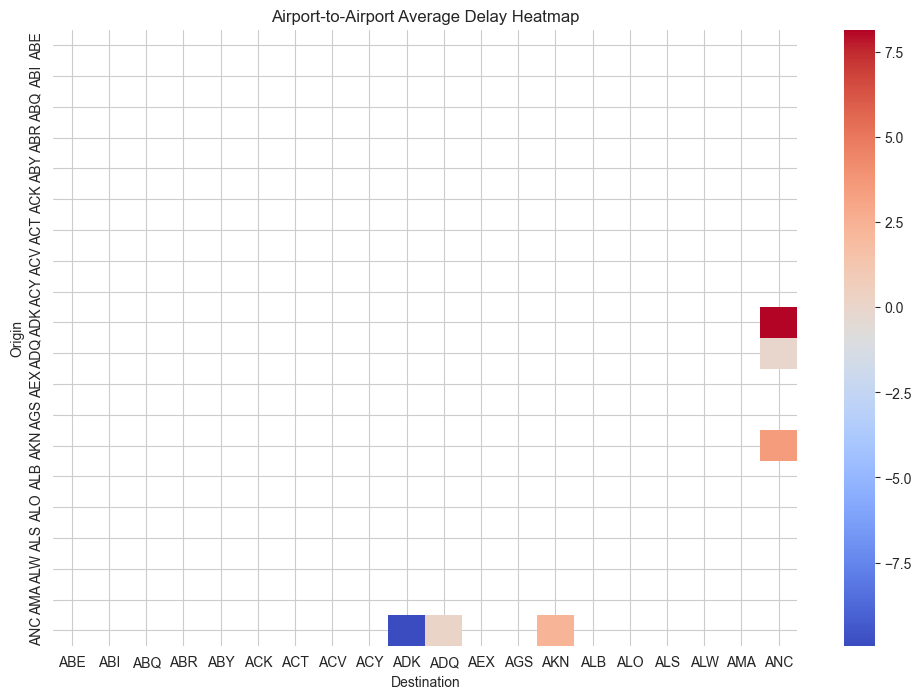

In [19]:
#AIRPORT HEATMAP ANALYSIS

#Origin vs Destination Delay Heatmap
heatmap_data = active.pivot_table(
    values='ARR_DELAY',
    index='ORIGIN',
    columns='DEST',
    aggfunc='mean'
)

# Reduce size for clarity
heatmap_data = heatmap_data.iloc[:20, :20]

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap="coolwarm")

plt.title("Airport-to-Airport Average Delay Heatmap")
plt.xlabel("Destination")
plt.ylabel("Origin")
plt.show()

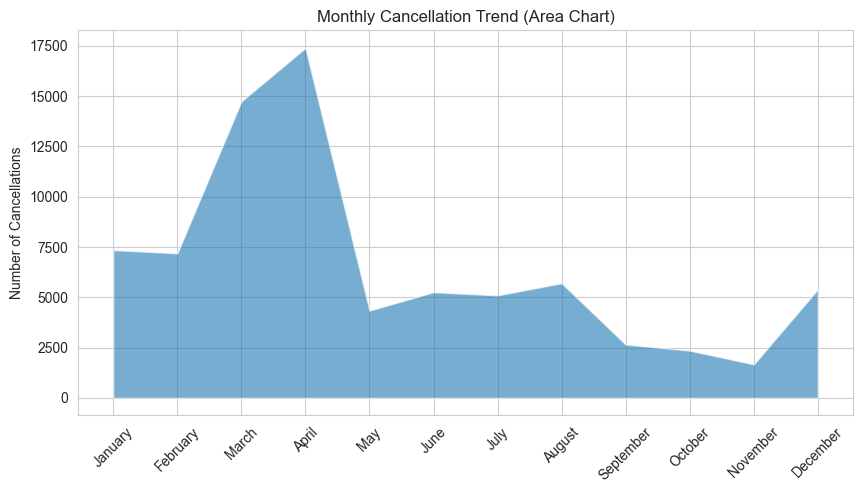

In [20]:
#CANCELLATION ANALYSIS

#Cancellation Trend by Month
cancel_trend = df.groupby('MONTH_NAME')['CANCELLED'].sum()

cancel_trend = cancel_trend.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,5))
plt.fill_between(cancel_trend.index, cancel_trend.values, alpha=0.6)

plt.xticks(rotation=45)
plt.title("Monthly Cancellation Trend (Area Chart)")
plt.ylabel("Number of Cancellations")
plt.show()

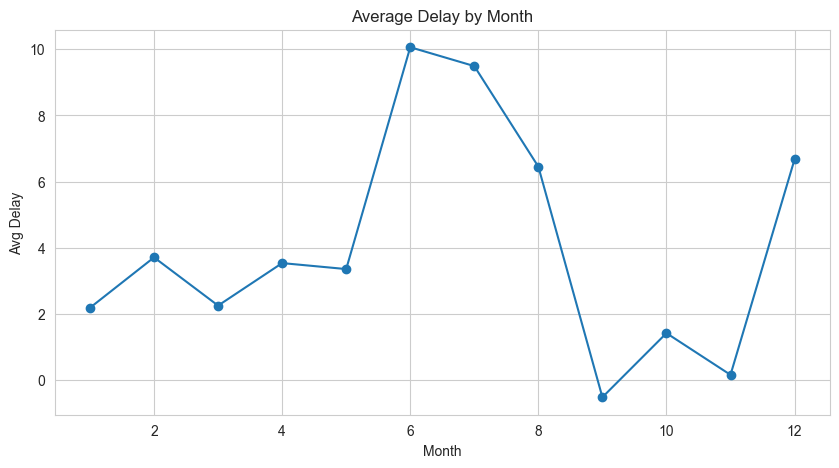

In [21]:
#SEASONAL ANALYSIS

#Monthly Delay Trend
monthly_delay = active.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_delay.index, monthly_delay.values, marker='o')

plt.title("Average Delay by Month")
plt.xlabel("Month")
plt.ylabel("Avg Delay")
plt.show()

In [22]:
print(active.columns)


Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT', 'YEAR', 'MONTH', 'MONTH_NAME', 'ROUTE'],
      dtype='str')


In [23]:
active['FL_DATE'] = pd.to_datetime(active['FL_DATE'])
active['WEEKDAY'] = active['FL_DATE'].dt.day_name()

In [25]:
print(active['ARR_DELAY'].head())

0   -14.0
1    -5.0
2     0.0
3    24.0
4    -1.0
Name: ARR_DELAY, dtype: float64


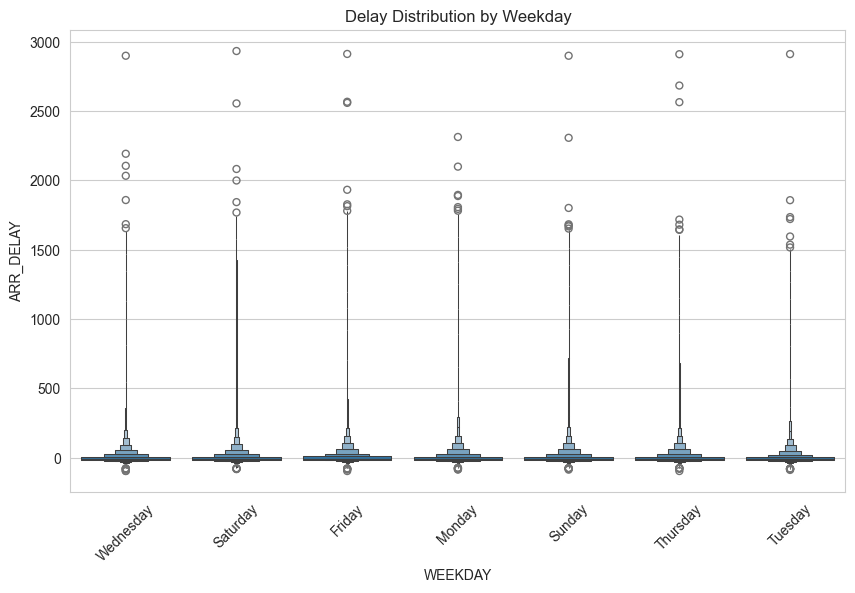

In [26]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='WEEKDAY',
    y='ARR_DELAY',
    data=active
)

plt.xticks(rotation=45)
plt.title("Delay Distribution by Weekday")
plt.show()

In [27]:
#MAP VISUALIZATION

#Flights by Origin City (Interactive Map)
map_data = active.groupby(['ORIGIN_CITY']).size().reset_index(name='FLIGHTS')

fig = px.scatter_geo(
    map_data,
    locations=None,
    locationmode="USA-states",
    size="FLIGHTS",
    hover_name="ORIGIN_CITY",
    title="Flights Distribution by City"
)

fig.show()